# LeetCode #114: Flatten Binary Tree to Linked List

https://leetcode.com/problems/flatten-binary-tree-to-linked-list/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Recursive post-order | O(n) | O(n) | Flatten subtrees then reconnect |
| Iterative with Stack | O(n) | O(n) | Simulate pre-order traversal |
| **Morris-style O(1) space ★** | **O(n)** | **O(1)** | In-place rewiring; find rightmost of left subtree |

---

## Understanding the Methods

### Recursive
Flatten left and right subtrees. Connect the tail of flattened left to the head of flattened right. O(n) time and space.

### Morris-style Iterative O(1) Space (Optimal ★)
For each node with a left child: find the rightmost node of the left subtree, attach current's right subtree there, move left subtree to right, null out left. Advance. O(n) total — each edge traversed at most twice.

## Constraints
- Number of nodes: [0, 2000]
- Node values: [-100, 100]
- Must be done in-place with O(1) extra space

## Solutions

### C#

In [ ]:
public class Solution {
    public void Flatten(TreeNode root) {
        var cur = root;
        while (cur != null) {
            if (cur.left != null) {
                // find rightmost of left subtree
                var rightmost = cur.left;
                while (rightmost.right != null) rightmost = rightmost.right;
                // connect
                rightmost.right = cur.right;
                cur.right       = cur.left;
                cur.left        = null;
            }
            cur = cur.right;
        }
    }
}

### Python

In [ ]:
class Solution:
    def flatten(self, root) -> None:
        cur = root
        while cur:
            if cur.left:
                rightmost = cur.left
                while rightmost.right:
                    rightmost = rightmost.right
                rightmost.right = cur.right
                cur.right       = cur.left
                cur.left        = None
            cur = cur.right

### Go

In [ ]:
func flatten(root *TreeNode) {
    cur := root
    for cur != nil {
        if cur.Left != nil {
            rightmost := cur.Left
            for rightmost.Right != nil { rightmost = rightmost.Right }
            rightmost.Right = cur.Right
            cur.Right       = cur.Left
            cur.Left        = nil
        }
        cur = cur.Right
    }
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;

impl Solution {
    pub fn flatten(root: &mut Option<Rc<RefCell<TreeNode>>>) {
        let mut cur = root.clone();
        while let Some(node) = cur {
            if node.borrow().left.is_some() {
                // find rightmost of left subtree
                let mut rightmost = node.borrow().left.clone().unwrap();
                loop {
                    let next = rightmost.borrow().right.clone();
                    match next {
                        Some(n) => rightmost = n,
                        None    => break,
                    }
                }
                let right = node.borrow().right.clone();
                rightmost.borrow_mut().right = right;
                let left  = node.borrow().left.clone();
                node.borrow_mut().right = left;
                node.borrow_mut().left  = None;
            }
            cur = node.borrow().right.clone();
        }
    }
}

## Example Scenarios

### 1. Common Case — Standard Tree [1,2,5,3,4,null,6]
**Input:** `root = [1, 2, 5, 3, 4, null, 6]`

Step 1: Node 1 has left child 2. Rightmost of left subtree: $2 \to 5$? No, $2 \to \text{right} = 4$. So rightmost $= 4$. Wire: $4.\text{right} = 5$, $1.\text{right} = 2$, $1.\text{left} = \text{null}$. Continue until all nodes form a right chain in pre-order: $1 \to 2 \to 3 \to 4 \to 5 \to 6$.

*Why tricky:* Exercises both the "find rightmost" inner loop and the rewiring operation. Validates pre-order traversal order.

**Output:** `[1,null,2,null,3,null,4,null,5,null,6]`

### 2. Slightly Complex — Already Flat (Right-Only Chain)
**Input:** `root = [1, null, 2, null, 3, null, 4]`

No left children anywhere. The while loop advances `cur = cur.right` at each step without entering the if-branch. Zero rewiring operations.

*Why tricky:* Tests the no-op case. The algorithm should recognize the tree is already flat and do nothing.

**Output:** `[1,null,2,null,3,null,4]` (unchanged)

### 3. Edge Case: Time Factor — 2000-Node Left-Skewed Tree
**Input:** All 2000 nodes have only left children ($n = 2000$, max constraint)

Each step: `rightmost = cur.left` (single node, no inner right chain), so the rightmost search is $O(1)$ per step. Total: $O(n) = O(2000)$ rewire operations. Each edge traversed at most twice.

*Why tricky:* Maximum constraint with all-left skew. Every node triggers the rewire branch, but the rightmost search is trivially $O(1)$ each time.

**Output:** Right chain of 2000 nodes, $O(n)$ time, $O(1)$ space

### 4. Edge Case: Space Factor — Perfect Binary Tree of 15 Nodes
**Input:** `root = perfect tree [1..15]`, depth 3

Pre-order: $1,2,4,8,9,5,10,11,3,6,12,13,7,14,15$. The "find rightmost" loop traverses multiple hops (e.g., at node 1: $2 \to 5 \to 11$, 3 hops). Amortized across all steps, each edge is traversed at most twice, so total time $= O(n)$. Space $= O(1)$.

*Why tricky:* The nested loops (outer while + inner rightmost search) look like $O(n \log n)$, but amortized analysis shows $O(n)$ total since each edge is visited at most twice.

**Output:** `[1,null,2,null,4,...,null,15]` in pre-order

### 5. Almost-Impossible but Plausible — Single Node with Extreme Value
**Input:** `root = [-100]`

The while loop executes once: `cur = root`, `cur.left == null`, so `cur = cur.right = null` and the loop exits. Zero rewiring. Minimum node value ($-100$) and minimum tree size.

*Why tricky:* Boundary value with minimum tree size. Tests the degenerate case where the algorithm does nothing.

**Output:** `[-100]` (unchanged)

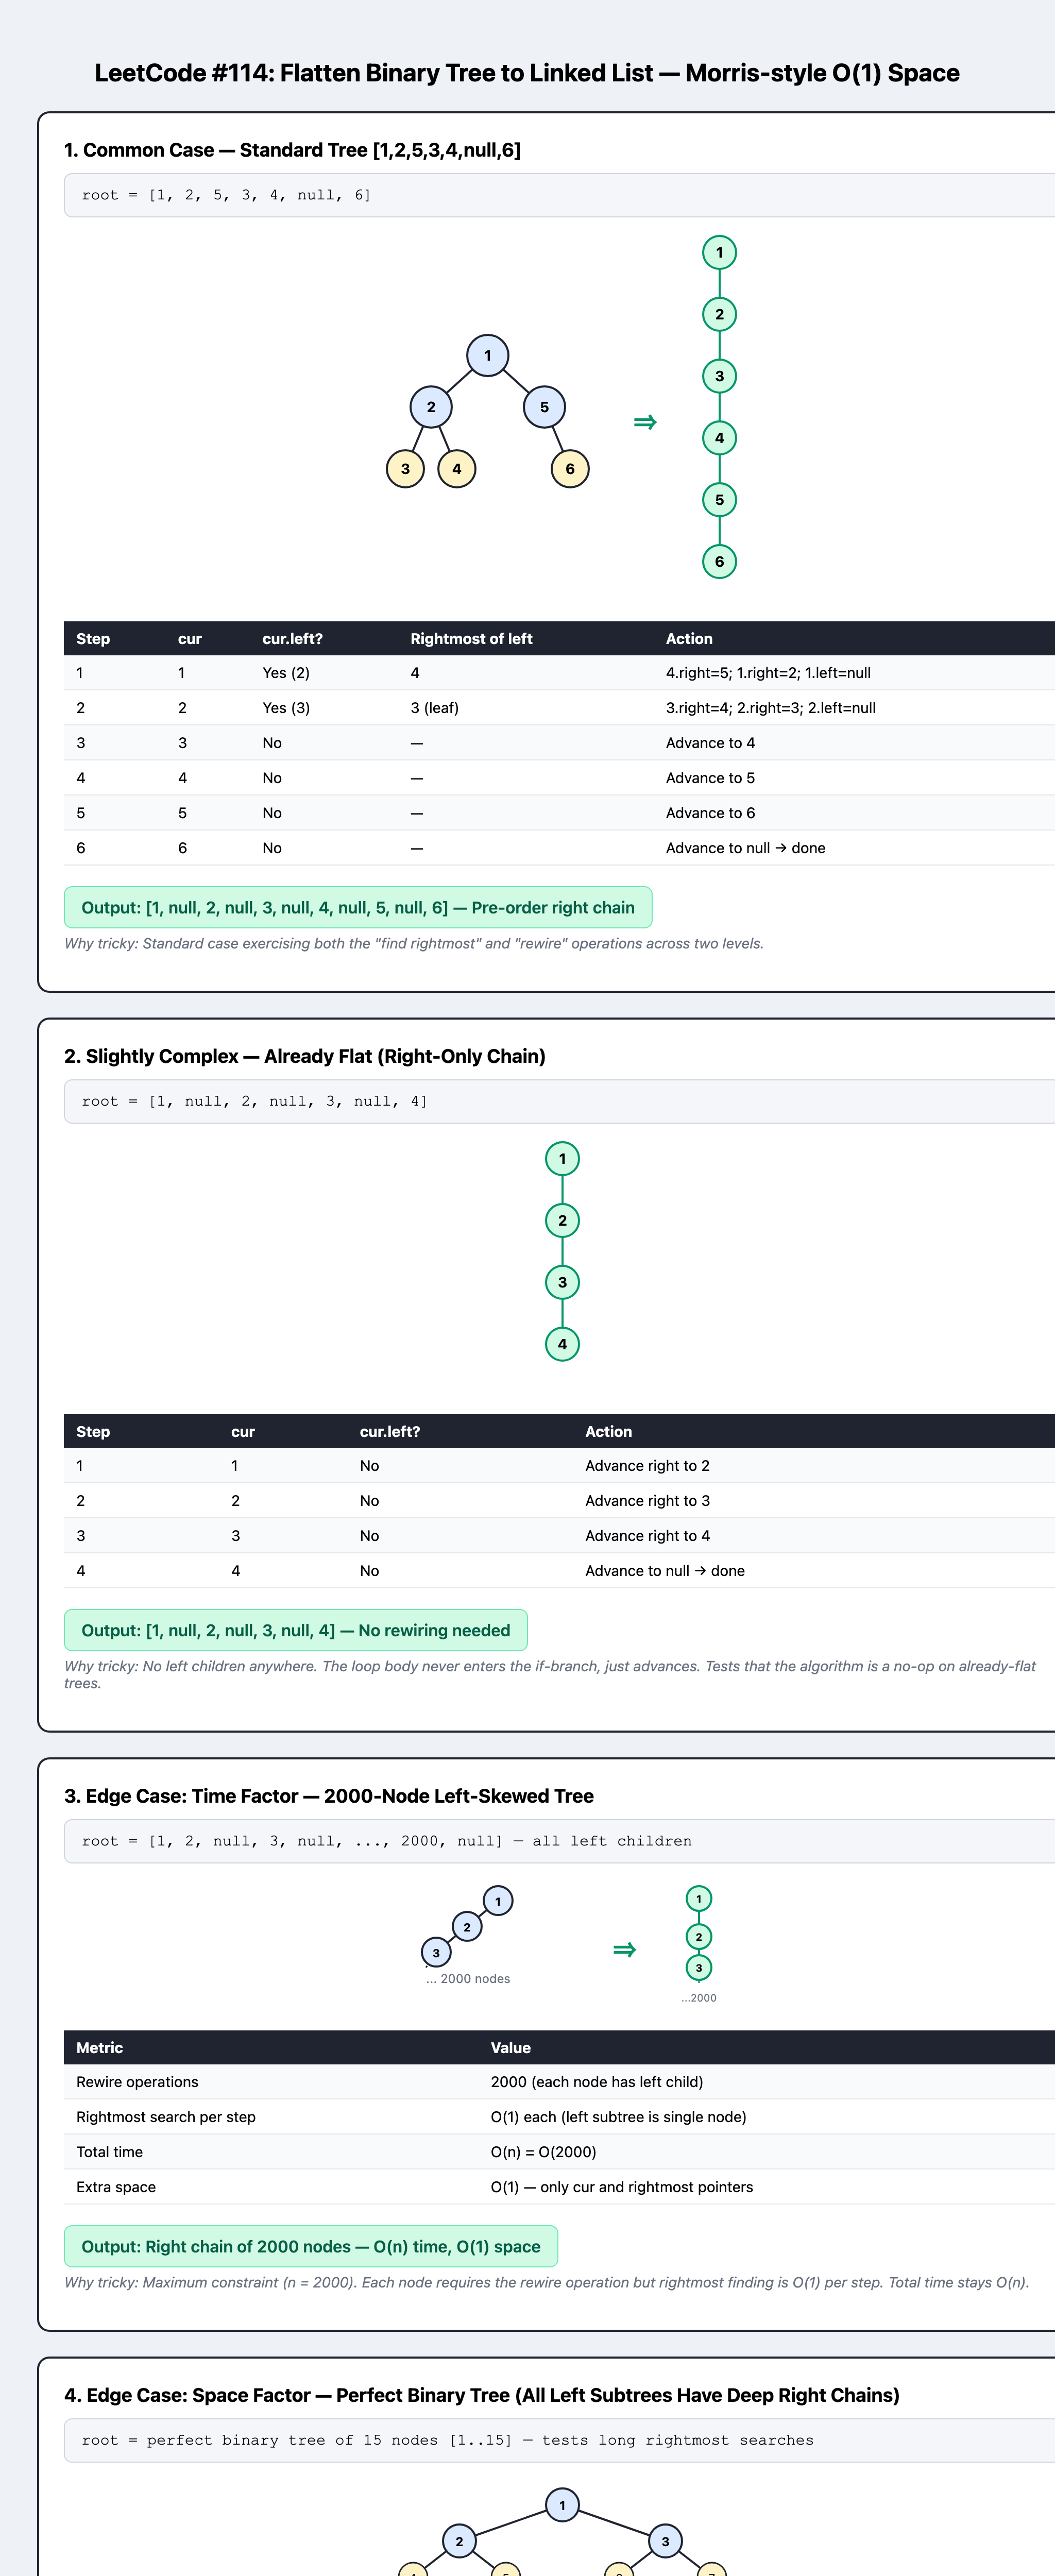